In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR    = Path("./emotion_data")
RAVDESS_DIR = BASE_DIR / "RAVDESS"
RAVDESS_DIR = BASE_DIR / "RAVDESS"          # your .wav files live here
OUTPUT_DIR  = BASE_DIR / "processed_ravdess"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Audio constants ───────────────────────────────────────────────────────────
SR           = 22050     # 22.05 kHz — preserves more of RAVDESS studio quality
                         # vs 16kHz used for phone/noisy speech
MAX_DURATION = 3.0       # seconds — RAVDESS utterances are 2–4s; 3s covers most
MAX_SAMPLES  = int(SR * MAX_DURATION)   # 66150 samples

# ── Spectrogram constants ─────────────────────────────────────────────────────
N_FFT       = 2048       # larger FFT window — better frequency resolution
                         # at 22050Hz: 2048 samples = ~93ms window
HOP_LENGTH  = 512        # 23ms hop — 75% overlap with 2048 window
N_MELS      = 128        # 128 bands — literature standard for clean speech
FMIN        = 20         # capture down to fundamental freq (80-180 Hz for voice)
FMAX        = 8000       # above 8kHz is mostly noise in emotional speech

N_FRAMES    = 1 + MAX_SAMPLES // HOP_LENGTH   # = 130 frames

print("=" * 50)
print("  RAVDESS Preprocessing Config")
print("=" * 50)
print(f"  Sample rate      : {SR} Hz")
print(f"  Max duration     : {MAX_DURATION}s ({MAX_SAMPLES} samples)")
print(f"  FFT window       : {N_FFT} ({N_FFT/SR*1000:.0f}ms)")
print(f"  Hop length       : {HOP_LENGTH} ({HOP_LENGTH/SR*1000:.0f}ms)")
print(f"  Mel bands        : {N_MELS}")
print(f"  Freq range       : {FMIN}–{FMAX} Hz")
print(f"  Output shape     : (1, {N_MELS}, {N_FRAMES})")
print("=" * 50)

  RAVDESS Preprocessing Config
  Sample rate      : 22050 Hz
  Max duration     : 3.0s (66150 samples)
  FFT window       : 2048 (93ms)
  Hop length       : 512 (23ms)
  Mel bands        : 128
  Freq range       : 20–8000 Hz
  Output shape     : (1, 128, 130)


In [3]:
# RAVDESS filename format:
# 03-01-06-01-02-01-12.wav
# └─ modality (03=audio-only)
#    └─ vocal channel (01=speech)
#       └─ emotion (01–08)
#          └─ intensity (01=normal, 02=strong)
#             └─ statement (01=Kids, 02=Dogs)
#                └─ repetition (01, 02)
#                   └─ actor (01–24, odd=male, even=female)

EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

# Keep all 8 — more classes = more data = better generalization
VALID_EMOTIONS = ['neutral', 'calm', 'happy', 'sad',
                  'angry',   'fearful', 'disgust', 'surprised']
LABEL_TO_INT   = {e: i for i, e in enumerate(VALID_EMOTIONS)}
INT_TO_LABEL   = {i: e for e, i in LABEL_TO_INT.items()}
NUM_CLASSES    = len(VALID_EMOTIONS)

print(f"Emotion classes ({NUM_CLASSES}):")
for i, e in INT_TO_LABEL.items():
    print(f"  {i}  {e}")

Emotion classes (8):
  0  neutral
  1  calm
  2  happy
  3  sad
  4  angry
  5  fearful
  6  disgust
  7  surprised


In [4]:
def parse_ravdess(ravdess_dir):
    """
    Walk all Actor_* subdirectories and parse every .wav filename.

    Returns a DataFrame with columns:
      filepath, emotion, label, actor_id, intensity, gender, source
    """
    records = []
    wav_files = list(Path(ravdess_dir).rglob("*.wav"))
    print(f"Found {len(wav_files)} .wav files")

    for fp in wav_files:
        parts = fp.stem.split('-')
        if len(parts) != 7:
            continue   # skip malformed filenames

        modality  = parts[0]   # 03 = audio-only speech
        emotion_c = parts[2]   # emotion code
        intensity = parts[3]   # 01=normal, 02=strong
        actor_id  = int(parts[6])

        # Skip song modality if present (02 = song)
        if modality != '03':
            continue

        emotion = EMOTION_MAP.get(emotion_c)
        if emotion not in VALID_EMOTIONS:
            continue

        # Actors: odd = male, even = female
        gender = 'male' if actor_id % 2 == 1 else 'female'

        records.append({
            'filepath'  : str(fp),
            'emotion'   : emotion,
            'label'     : LABEL_TO_INT[emotion],
            'actor_id'  : actor_id,       # 1–24, KEY for speaker-independent split
            'intensity' : intensity,       # 01 or 02
            'gender'    : gender,
        })

    df = pd.DataFrame(records).sort_values('filepath').reset_index(drop=True)
    return df


df = parse_ravdess(RAVDESS_DIR)

print(f"\nTotal files parsed : {len(df)}")
print(f"Actors found       : {sorted(df['actor_id'].unique())}")
print(f"\nEmotion distribution:")
ec = df['emotion'].value_counts()
for emotion, count in ec.items():
    bar = '█' * (count // 5)
    print(f"  {emotion:<12} {count:>4}  {bar}")

print(f"\nIntensity split:")
print(df['intensity'].value_counts().to_string())
print(f"\nGender split:")
print(df['gender'].value_counts().to_string())

Found 2880 .wav files

Total files parsed : 2880
Actors found       : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]

Emotion distribution:
  calm          384  ████████████████████████████████████████████████████████████████████████████
  happy         384  ████████████████████████████████████████████████████████████████████████████
  sad           384  ████████████████████████████████████████████████████████████████████████████
  angry         384  ████████████████████████████████████████████████████████████████████████████
  fearful       384  ████████████████████████████████████████████████████████████████████████████
  disgust       384  ████████████████████████████████████████████████████████████████████

In [5]:
# RAVDESS has 24 actors.
# Most literature uses Leave-One-Speaker-Out (LOSO) cross-validation.
# For a single train/val/test run we do a speaker-level stratified split:
#
#   Train  : actors 1–16  (67%) — 8M + 8F, balanced gender
#   Val    : actors 17–20 (17%) — 2M + 2F
#   Test   : actors 21–24 (16%) — 2M + 2F
#
# WHY speaker-independent?
# If actor 5 appears in both train and test, the model partially learns
# that actor's voice timbre — not the emotion. On RAVDESS this can inflate
# accuracy by 10-15% vs a true speaker-independent evaluation.
# Every serious RAVDESS paper uses speaker-independent splits.

TRAIN_ACTORS = list(range(1,  17))    # 16 actors
VAL_ACTORS   = list(range(17, 21))    #  4 actors
TEST_ACTORS  = list(range(21, 25))    #  4 actors

train_df = df[df['actor_id'].isin(TRAIN_ACTORS)].reset_index(drop=True)
val_df   = df[df['actor_id'].isin(VAL_ACTORS)].reset_index(drop=True)
test_df  = df[df['actor_id'].isin(TEST_ACTORS)].reset_index(drop=True)

print("Speaker-independent split")
print("=" * 52)
print(f"  {'Split':<8} {'Files':>6}  {'Actors'}")
print(f"  {'─'*48}")
print(f"  {'Train':<8} {len(train_df):>6}  actors {TRAIN_ACTORS}")
print(f"  {'Val':<8} {len(val_df):>6}  actors {VAL_ACTORS}")
print(f"  {'Test':<8} {len(test_df):>6}  actors {TEST_ACTORS}")
print(f"  {'─'*48}")
print(f"  {'Total':<8} {len(df):>6}")

print(f"\nClass distribution per split:")
for name, sdf in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    counts = sdf['emotion'].value_counts()
    print(f"\n  {name}:")
    for e in VALID_EMOTIONS:
        n = counts.get(e, 0)
        print(f"    {e:<12} {n:>4}")

Speaker-independent split
  Split     Files  Actors
  ────────────────────────────────────────────────
  Train      1920  actors [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
  Val         480  actors [17, 18, 19, 20]
  Test        480  actors [21, 22, 23, 24]
  ────────────────────────────────────────────────
  Total      2880

Class distribution per split:

  Train:
    neutral       128
    calm          256
    happy         256
    sad           256
    angry         256
    fearful       256
    disgust       256
    surprised     256

  Val:
    neutral        32
    calm           64
    happy          64
    sad            64
    angry          64
    fearful        64
    disgust        64
    surprised      64

  Test:
    neutral        32
    calm           64
    happy          64
    sad            64
    angry          64
    fearful        64
    disgust        64
    surprised      64


In [6]:
def load_and_clean(filepath, sr=SR, max_samples=MAX_SAMPLES, top_db=30):
    """
    Load a RAVDESS .wav and return a fixed-length cleaned waveform.

    RAVDESS-specific choices:
      - top_db=30: RAVDESS is studio-recorded with very clean silence boundaries.
        30dB is aggressive and appropriate — removes dead air without clipping
        the actual utterance.
      - Centre-crop: RAVDESS actors often have silence at both ends.
        Taking the centre keeps the peak emotional content.
      - No stereo conversion needed — RAVDESS speech is already mono.
    """
    y, _ = librosa.load(filepath, sr=sr, mono=True)

    # Trim silence
    y_t, _ = librosa.effects.trim(y, top_db=top_db)
    if len(y_t) < sr * 0.1:    # if trim ate too much (silent file), revert
        y_t = y

    # Peak normalise to [-1, 1]
    peak = np.max(np.abs(y_t))
    if peak > 0:
        y_t = y_t / peak

    # Fixed length: centre-crop or zero-pad
    if len(y_t) >= max_samples:
        start = (len(y_t) - max_samples) // 2
        y_out = y_t[start : start + max_samples]
    else:
        pad   = max_samples - len(y_t)
        y_out = np.pad(y_t, (pad // 2, pad - pad // 2))   # pad symmetrically

    return y_out.astype(np.float32)


# ── Quick sanity check ────────────────────────────────────────────────────────
_y = load_and_clean(df.iloc[0]['filepath'])
print(f"Output shape  : {_y.shape}  (expected {MAX_SAMPLES})")
print(f"Duration      : {len(_y)/SR:.3f}s")
print(f"Amplitude     : [{_y.min():.4f}, {_y.max():.4f}]")
del _y

Output shape  : (66150,)  (expected 66150)
Duration      : 3.000s
Amplitude     : [-0.9227, 1.0000]


In [7]:
def extract_mel(y, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH,
                n_mels=N_MELS, fmin=FMIN, fmax=FMAX, n_frames=N_FRAMES):
    """
    Convert waveform → log-mel spectrogram → instance-normalised image.

    Returns: np.ndarray shape (1, N_MELS, N_FRAMES) = (1, 128, 130), float32

    RAVDESS-specific choices:
      N_FFT=2048 at 22050Hz: 93ms window — long enough to resolve
      the fundamental frequency (male F0 ~80-150 Hz needs ≥7ms, but
      formants and prosodic shape need longer windows).

      128 mel bands: RAVDESS is clean studio audio. 128 vs 64 gives
      2x finer frequency resolution — captures formant micro-structure
      that distinguishes e.g. calm from neutral or happy from surprised.
    """
    mel    = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length,
        n_mels=n_mels, fmin=fmin, fmax=fmax)

    mel_db = librosa.power_to_db(mel, ref=np.max)     # (128, T)

    # Instance normalisation: each file normalised to its own [0, 1]
    # The model learns from the SHAPE of the spectrogram, not absolute energy.
    vmin, vmax = mel_db.min(), mel_db.max()
    if vmax - vmin > 1e-6:
        mel_norm = (mel_db - vmin) / (vmax - vmin)
    else:
        mel_norm = np.zeros_like(mel_db)

    # Fix time axis — librosa may give T = n_frames ± 1
    T = mel_norm.shape[1]
    if T >= n_frames:
        mel_norm = mel_norm[:, :n_frames]
    else:
        mel_norm = np.pad(mel_norm, ((0, 0), (0, n_frames - T)))

    return mel_norm[np.newaxis, :, :].astype(np.float32)   # (1, 128, 130)


# ── Quick sanity check ────────────────────────────────────────────────────────
_y   = load_and_clean(df.iloc[0]['filepath'])
_s   = extract_mel(_y)
print(f"Spectrogram shape : {_s.shape}   (C, mel_bands, time_frames)")
print(f"Value range       : [{_s.min():.4f}, {_s.max():.4f}]  (should be 0–1)")
print(f"Expected          : (1, {N_MELS}, {N_FRAMES})")
del _y, _s

Spectrogram shape : (1, 128, 130)   (C, mel_bands, time_frames)
Value range       : [0.0000, 1.0000]  (should be 0–1)
Expected          : (1, 128, 130)


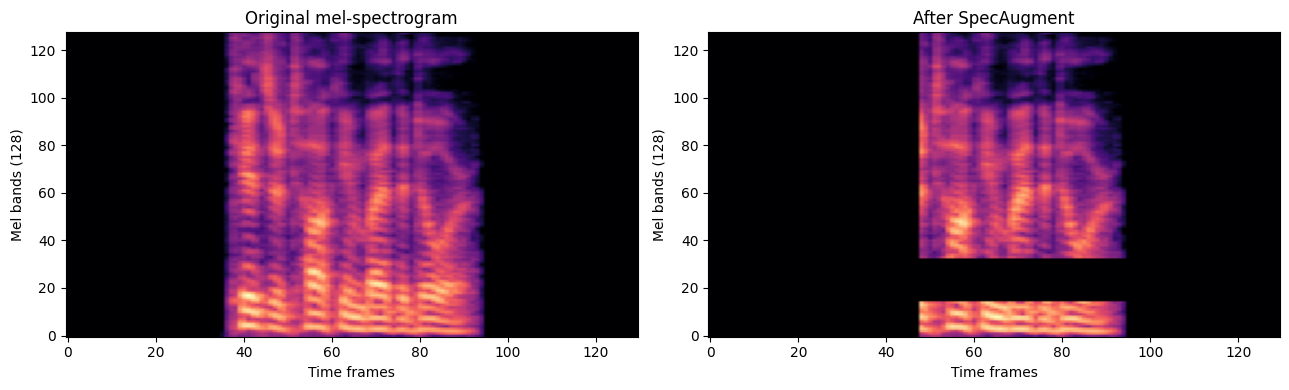

In [8]:
def spec_augment(spec, freq_mask=16, time_mask=26,
                 n_freq_masks=2, n_time_masks=2):
    """
    SpecAugment data augmentation (Park et al., 2019).

    RAVDESS-specific parameters:
      freq_mask=16  → up to 16/128 = 12.5% of mel bands masked per stripe
      time_mask=26  → up to 26/130 = 20% of time frames masked per stripe
      n_freq_masks=2, n_time_masks=2 → two stripes each

    More aggressive than the previous pipeline (freq=8, time=20) because
    RAVDESS is small (~1440 files) and overfitting is the main risk.
    """
    aug = spec.copy()
    _, F, T = aug.shape

    for _ in range(n_freq_masks):
        f  = np.random.randint(1, freq_mask + 1)
        f0 = np.random.randint(0, max(1, F - f))
        aug[0, f0 : f0 + f, :] = 0.0

    for _ in range(n_time_masks):
        t  = np.random.randint(1, time_mask + 1)
        t0 = np.random.randint(0, max(1, T - t))
        aug[0, :, t0 : t0 + t] = 0.0

    return aug


# ── Visualise ─────────────────────────────────────────────────────────────────
_y   = load_and_clean(df.iloc[0]['filepath'])
_s   = extract_mel(_y)
_sa  = spec_augment(_s)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.imshow(_s[0],  aspect='auto', origin='lower', cmap='magma')
ax1.set_title("Original mel-spectrogram")
ax2.imshow(_sa[0], aspect='auto', origin='lower', cmap='magma')
ax2.set_title("After SpecAugment")
for ax in [ax1, ax2]:
    ax.set_xlabel("Time frames"); ax.set_ylabel("Mel bands (128)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "specaugment_example.png", dpi=150)
plt.show()
del _y, _s, _sa

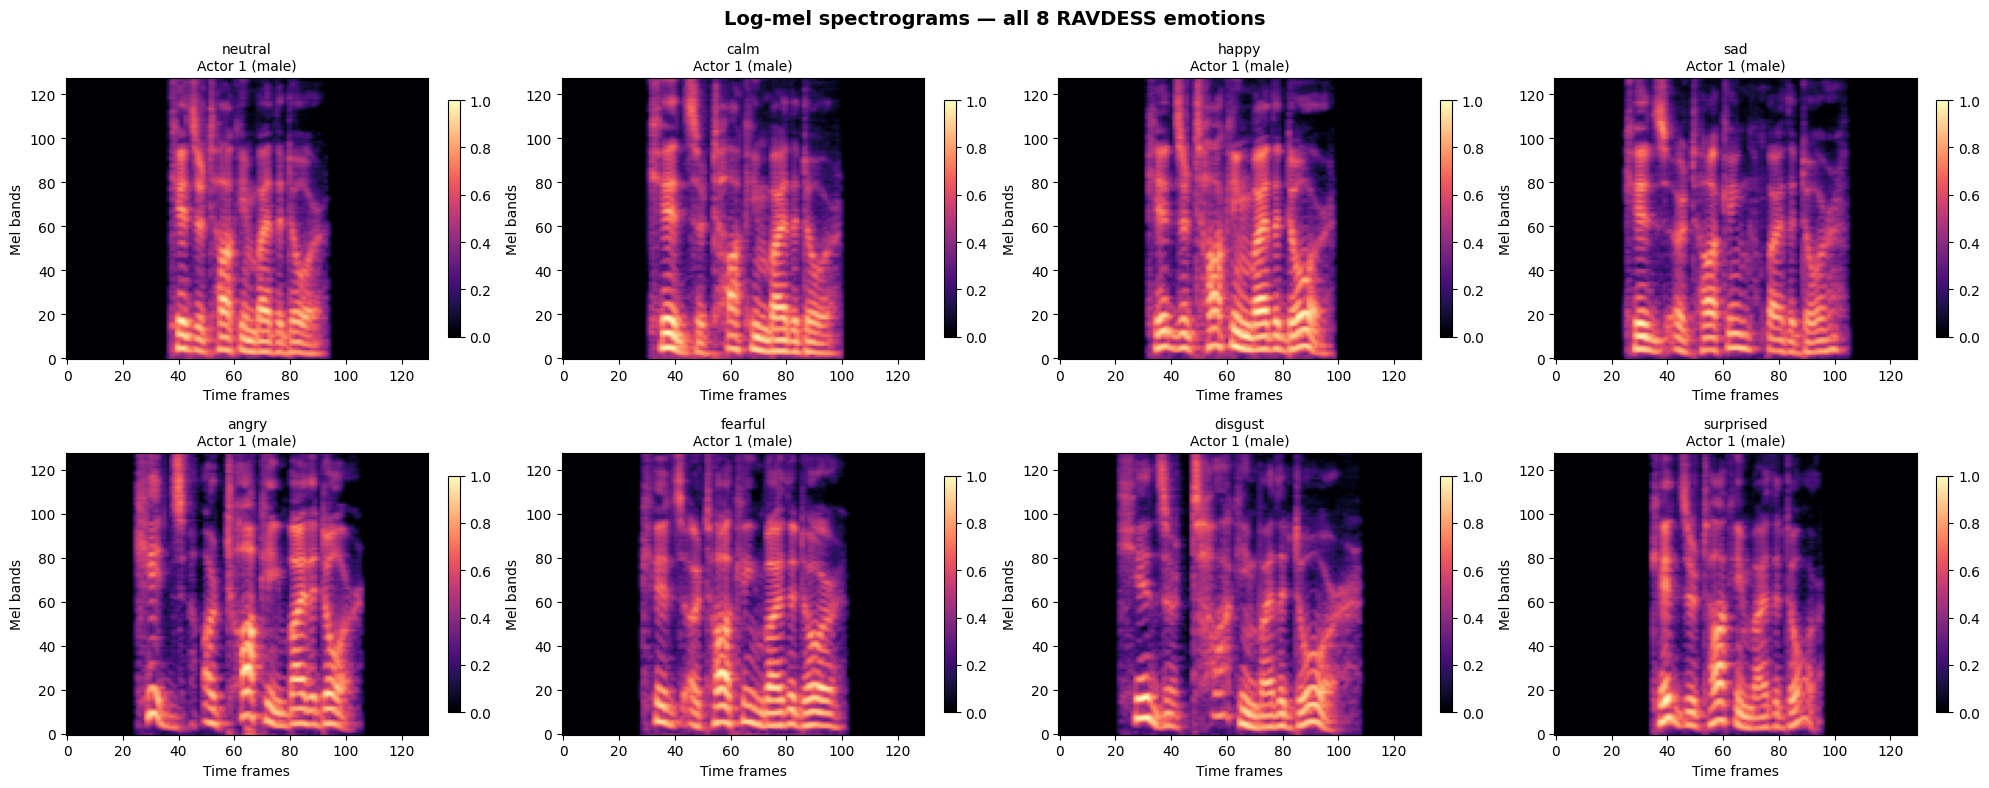

Saved → all_emotions_spectrograms.png


In [9]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("Log-mel spectrograms — all 8 RAVDESS emotions", fontsize=14, fontweight='bold')

for ax, emotion in zip(axes.flatten(), VALID_EMOTIONS):
    row  = df[df['emotion'] == emotion].iloc[0]
    y_ex = load_and_clean(row['filepath'])
    spec = extract_mel(y_ex)[0]

    img = ax.imshow(spec, aspect='auto', origin='lower',
                    cmap='magma', vmin=0, vmax=1)
    ax.set_title(f"{emotion}\nActor {row['actor_id']} ({row['gender']})", fontsize=10)
    ax.set_xlabel("Time frames")
    ax.set_ylabel("Mel bands")
    plt.colorbar(img, ax=ax, fraction=0.03)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "all_emotions_spectrograms.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → all_emotions_spectrograms.png")

In [10]:
def process_split(split_df, split_name, augment=False):
    """
    Extract mel-spectrograms for every file in a split.
    If augment=True, also produces one SpecAugment copy per file
    (only used for training).
    """
    X_list, y_list, meta = [], [], []
    failed = []

    for _, row in tqdm(split_df.iterrows(),
                       total=len(split_df), desc=f"  {split_name}"):
        try:
            y_wav = load_and_clean(row['filepath'])
            spec  = extract_mel(y_wav)

            X_list.append(spec)
            y_list.append(row['label'])
            meta.append({
                'filepath': row['filepath'],
                'emotion':  row['emotion'],
                'label':    row['label'],
                'actor_id': row['actor_id'],
                'augmented': False
            })

            if augment:
                X_list.append(spec_augment(spec))
                y_list.append(row['label'])
                meta.append({
                    'filepath': row['filepath'],
                    'emotion':  row['emotion'],
                    'label':    row['label'],
                    'actor_id': row['actor_id'],
                    'augmented': True
                })

        except Exception as e:
            failed.append((row['filepath'], str(e)))

    if failed:
        print(f"\n  ✗ {len(failed)} files failed:")
        for fp, err in failed[:5]:
            print(f"    {Path(fp).name} → {err}")

    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int64)
    return X, y, pd.DataFrame(meta)


print("Processing splits...\n")
X_train, y_train, meta_train = process_split(train_df, "Train", augment=True)
X_val,   y_val,   meta_val   = process_split(val_df,   "Val",   augment=False)
X_test,  y_test,  meta_test  = process_split(test_df,  "Test",  augment=False)

print(f"\n{'='*50}")
print(f"  {'Split':<8}  {'Shape':<22}  Files")
print(f"  {'─'*46}")
print(f"  {'Train':<8}  {str(X_train.shape):<22}  (orig + aug)")
print(f"  {'Val':<8}  {str(X_val.shape):<22}")
print(f"  {'Test':<8}  {str(X_test.shape):<22}")
print(f"{'='*50}")

Processing splits...



  Test: 100%|██████████| 480/480 [00:07<00:00, 65.21it/s]


  Split     Shape                   Files
  ──────────────────────────────────────────────
  Train     (3840, 1, 128, 130)     (orig + aug)
  Val       (480, 1, 128, 130)    
  Test      (480, 1, 128, 130)    


In [11]:
# ── Diagnose the imbalance ────────────────────────────────────────────────────
print("Class counts in training set (before fix):")
for i in range(NUM_CLASSES):
    n   = (y_train == i).sum()
    bar = '█' * (n // 8)
    print(f"  {INT_TO_LABEL[i]:<12} {n:>4}  {bar}")

neutral_label  = LABEL_TO_INT['neutral']
majority_count = (y_train != neutral_label).sum() // (NUM_CLASSES - 1)
neutral_count  = (y_train == neutral_label).sum()
needed         = majority_count - neutral_count

print(f"\nMajority class count : {majority_count}")
print(f"Neutral count        : {neutral_count}")
print(f"Extra neutral needed : {needed}")

Class counts in training set (before fix):
  neutral       256  ████████████████████████████████
  calm          512  ████████████████████████████████████████████████████████████████
  happy         512  ████████████████████████████████████████████████████████████████
  sad           512  ████████████████████████████████████████████████████████████████
  angry         512  ████████████████████████████████████████████████████████████████
  fearful       512  ████████████████████████████████████████████████████████████████
  disgust       512  ████████████████████████████████████████████████████████████████
  surprised     512  ████████████████████████████████████████████████████████████████

Majority class count : 512
Neutral count        : 256
Extra neutral needed : 256


In [12]:
def augment_diverse(spec):
    """
    Applies one of 4 augmentation strategies randomly.
    More variety than plain SpecAugment — important when oversampling
    because identical copies would just cause memorisation.

    Strategies:
      0 — SpecAugment (freq + time masking)
      1 — Gaussian noise added to the spectrogram values
      2 — Time shift: roll the spectrogram along the time axis
      3 — Freq shift: roll along the frequency axis (simulates pitch shift)
    """
    aug = spec.copy()
    strategy = np.random.randint(0, 4)

    if strategy == 0:
        # SpecAugment — same as before
        aug = spec_augment(aug, freq_mask=16, time_mask=26,
                           n_freq_masks=2, n_time_masks=2)

    elif strategy == 1:
        # Additive Gaussian noise on spectrogram values
        noise    = np.random.normal(0, 0.02, aug.shape).astype(np.float32)
        aug      = np.clip(aug + noise, 0.0, 1.0)

    elif strategy == 2:
        # Time shift: circular roll along time axis by up to ±15% of frames
        shift    = np.random.randint(-19, 20)     # ±15% of 130 frames
        aug[0]   = np.roll(aug[0], shift, axis=1)
        # Zero out the wrapped region to avoid label leakage
        if shift > 0:
            aug[0, :, :shift]  = 0.0
        elif shift < 0:
            aug[0, :, shift:]  = 0.0

    elif strategy == 3:
        # Frequency shift: circular roll along mel axis by up to ±5 bands
        shift    = np.random.randint(-5, 6)
        aug[0]   = np.roll(aug[0], shift, axis=0)
        if shift > 0:
            aug[0, :shift, :]  = 0.0
        elif shift < 0:
            aug[0, shift:, :]  = 0.0

    return aug


# ── Pull existing neutral spectrograms from training set ─────────────────────
neutral_mask   = y_train == neutral_label
X_neutral_orig = X_train[neutral_mask]    # all current neutral samples

# ── Generate `needed` extra copies ───────────────────────────────────────────
np.random.seed(42)
extra_X, extra_y = [], []

for i in range(needed):
    # Cycle through original neutral samples so each is used roughly equally
    src_spec = X_neutral_orig[i % len(X_neutral_orig)]
    extra_X.append(augment_diverse(src_spec))
    extra_y.append(neutral_label)

extra_X = np.stack(extra_X).astype(np.float32)
extra_y = np.array(extra_y, dtype=np.int64)

# ── Append to training arrays ────────────────────────────────────────────────
X_train = np.concatenate([X_train, extra_X], axis=0)
y_train = np.concatenate([y_train, extra_y], axis=0)

# ── Shuffle so augmented neutrals aren't all bunched at the end ──────────────
shuffle_idx = np.random.permutation(len(X_train))
X_train     = X_train[shuffle_idx]
y_train     = y_train[shuffle_idx]

# ── Verify ────────────────────────────────────────────────────────────────────
print("Class counts in training set (after fix):")
for i in range(NUM_CLASSES):
    n   = (y_train == i).sum()
    bar = '█' * (n // 8)
    print(f"  {INT_TO_LABEL[i]:<12} {n:>4}  {bar}")

print(f"\nX_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")

Class counts in training set (after fix):
  neutral       512  ████████████████████████████████████████████████████████████████
  calm          512  ████████████████████████████████████████████████████████████████
  happy         512  ████████████████████████████████████████████████████████████████
  sad           512  ████████████████████████████████████████████████████████████████
  angry         512  ████████████████████████████████████████████████████████████████
  fearful       512  ████████████████████████████████████████████████████████████████
  disgust       512  ████████████████████████████████████████████████████████████████
  surprised     512  ████████████████████████████████████████████████████████████████

X_train shape : (4096, 1, 128, 130)
y_train shape : (4096,)


In [15]:
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# In your training notebook, replace the class weight computation with this:
counts    = np.bincount(y_train, minlength=NUM_CLASSES).astype(np.float32)
# After oversampling neutral counts should be ~equal, so weights ~1.0
# but this guards against any residual imbalance
class_w   = (1.0 / counts) / (1.0 / counts).sum() * NUM_CLASSES
cw_tensor = torch.tensor(class_w, dtype=torch.float32).to(DEVICE)
print("Class weights (should all be close to 1.0 now):")
for i in range(NUM_CLASSES):
    print(f"  {INT_TO_LABEL[i]:<12}  count={int(counts[i]):>4}  weight={class_w[i]:.4f}")

Class weights (should all be close to 1.0 now):
  neutral       count= 512  weight=1.0000
  calm          count= 512  weight=1.0000
  happy         count= 512  weight=1.0000
  sad           count= 512  weight=1.0000
  angry         count= 512  weight=1.0000
  fearful       count= 512  weight=1.0000
  disgust       count= 512  weight=1.0000
  surprised     count= 512  weight=1.0000


In [16]:
# ── Save numpy arrays ─────────────────────────────────────────────────────────
np.save(OUTPUT_DIR / "X_train.npy",  X_train)
np.save(OUTPUT_DIR / "y_train.npy",  y_train)
np.save(OUTPUT_DIR / "X_val.npy",    X_val)
np.save(OUTPUT_DIR / "y_val.npy",    y_val)
np.save(OUTPUT_DIR / "X_test.npy",   X_test)
np.save(OUTPUT_DIR / "y_test.npy",   y_test)

# ── Save metadata ─────────────────────────────────────────────────────────────
meta_train.to_csv(OUTPUT_DIR / "meta_train.csv", index=False)
meta_val.to_csv(OUTPUT_DIR   / "meta_val.csv",   index=False)
meta_test.to_csv(OUTPUT_DIR  / "meta_test.csv",  index=False)

# ── Save label map + config ───────────────────────────────────────────────────
config = {
    'label_to_int' : LABEL_TO_INT,
    'int_to_label' : INT_TO_LABEL,
    'num_classes'  : NUM_CLASSES,
    'sr'           : SR,
    'max_duration' : MAX_DURATION,
    'n_fft'        : N_FFT,
    'hop_length'   : HOP_LENGTH,
    'n_mels'       : N_MELS,
    'fmin'         : FMIN,
    'fmax'         : FMAX,
    'n_frames'     : N_FRAMES,
    'train_actors' : TRAIN_ACTORS,
    'val_actors'   : VAL_ACTORS,
    'test_actors'  : TEST_ACTORS,
}
with open(OUTPUT_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved files:")
for p in sorted(OUTPUT_DIR.iterdir()):
    mb = p.stat().st_size / (1024**2)
    print(f"  {p.name:<30}  {mb:>6.1f} MB")

Saved files:
  all_emotions_spectrograms.png      0.4 MB
  config.json                        0.0 MB
  meta_test.csv                      0.0 MB
  meta_train.csv                     0.3 MB
  meta_val.csv                       0.0 MB
  specaugment_example.png            0.1 MB
  X_test.npy                        30.5 MB
  X_train.npy                      260.0 MB
  X_val.npy                         30.5 MB
  y_test.npy                         0.0 MB
  y_train.npy                        0.0 MB
  y_val.npy                          0.0 MB


In [17]:
# Reload from disk and verify everything is correct
X_tr = np.load(OUTPUT_DIR / "X_train.npy")
y_tr = np.load(OUTPUT_DIR / "y_train.npy")
X_v  = np.load(OUTPUT_DIR / "X_val.npy")
y_v  = np.load(OUTPUT_DIR / "y_val.npy")
X_te = np.load(OUTPUT_DIR / "X_test.npy")
y_te = np.load(OUTPUT_DIR / "y_test.npy")

print("=" * 55)
print("  Final dataset summary")
print("=" * 55)
for name, X, y in [("Train", X_tr, y_tr), ("Val", X_v, y_v), ("Test", X_te, y_te)]:
    print(f"\n  {name}")
    print(f"    X : {X.shape}  dtype={X.dtype}")
    print(f"    y : {y.shape}  dtype={y.dtype}")
    print(f"    range  : [{X.min():.4f}, {X.max():.4f}]")
    print(f"    NaN    : {np.isnan(X).any()}   Inf: {np.isinf(X).any()}")
    print(f"    Classes:")
    for i in range(NUM_CLASSES):
        n   = (y == i).sum()
        bar = '█' * (n // 5)
        print(f"      {INT_TO_LABEL[i]:<12} {n:>4}  {bar}")

print("\n" + "=" * 55)
print(f"  Input shape to model : (B, 1, {N_MELS}, {N_FRAMES})")
print(f"  = (batch, 1 channel, {N_MELS} mel bands, {N_FRAMES} time frames)")
print("=" * 55)

  Final dataset summary

  Train
    X : (4096, 1, 128, 130)  dtype=float32
    y : (4096,)  dtype=int64
    range  : [0.0000, 1.0000]
    NaN    : False   Inf: False
    Classes:
      neutral       512  ██████████████████████████████████████████████████████████████████████████████████████████████████████
      calm          512  ██████████████████████████████████████████████████████████████████████████████████████████████████████
      happy         512  ██████████████████████████████████████████████████████████████████████████████████████████████████████
      sad           512  ██████████████████████████████████████████████████████████████████████████████████████████████████████
      angry         512  ██████████████████████████████████████████████████████████████████████████████████████████████████████
      fearful       512  ██████████████████████████████████████████████████████████████████████████████████████████████████████
      disgust       512  ███████████████████████████